Enter incoming traffic rate (lambda) [ex. 500]:  500
Enter router processing rate (mu) [ex. 400]:  400
Enter RED drop probability factor (k) [ex. 0.3]:  0.3
Enter initial queue length (Q0) [ex. 350]:  350
Enter total simulation time in seconds [ex. 100]:  100


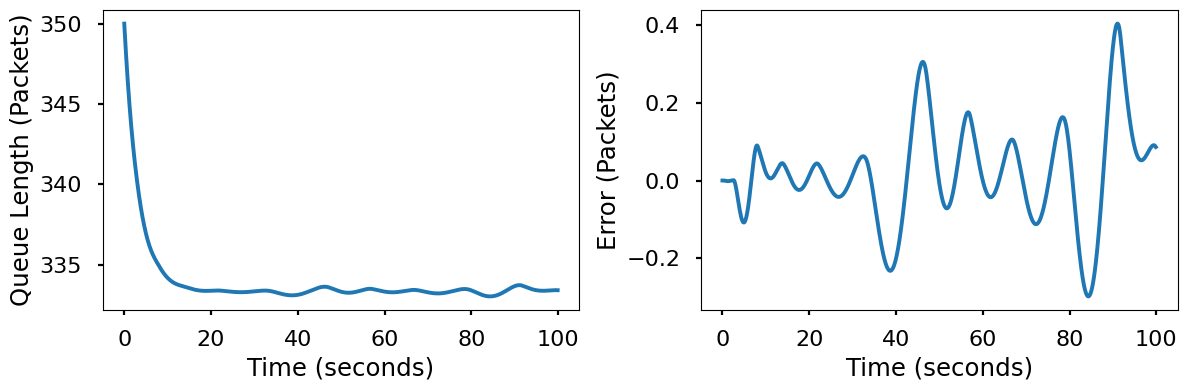

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

# Set the visual style for the plots
plt.style.use('seaborn-v0_8-poster')

# Define the Ordinary Differential Equation (ODE) using a lambda function
# This represents dq(t)/dt = lambda(t) - mu(t) - k * q(t)
# t: time, q: current queue length, lam: incoming traffic rate, mu: router processing rate, k: RED drop probability factor
F = lambda t, q, lam, mu, k: lam - mu - k * q

# Get user input for the parameters of the simulation
lam = float(input("Enter incoming traffic rate (lambda) [ex. 500]: "))
mu = float(input("Enter router processing rate (mu) [ex. 400]: "))
k = float(input("Enter RED drop probability factor (k) [ex. 0.3]: "))
q0 = float(input("Enter initial queue length (Q0) [ex. 350]: "))
t_max = float(input("Enter total simulation time in seconds [ex. 100]: "))

# Solve the ODE using solve_ivp
sol = solve_ivp(F, [0, t_max], [q0], t_eval=np.arange(0, t_max, 0.1), args=(lam, mu, k))

# Exact solution for the ODE, derived from the integrating factor method
# We will use this to compare against the numerical solution obtained from solve_ivp
F_exact = lambda t, q, lam, mu, k: q * np.exp(-k * t) + ((lam - mu) / k) * (1 - np.exp(-k * t))  # Exact solution for the ODE

# Plot the solutions plot and the error between the numerical and exact solutions
plt.figure(figsize = (12, 4))
plt.subplot(121)
plt.plot(sol.t, sol.y[0])
plt.xlabel('Time (seconds)')
plt.ylabel('Queue Length (Packets)')
plt.subplot(122)
plt.plot(sol.t, sol.y[0] - F_exact(sol.t, q0, lam, mu, k))
plt.xlabel('Time (seconds)')
plt.ylabel('Error (Packets)')
plt.tight_layout()
plt.show()